# IA de Reconnaissance de Chiffres Manuscrits
## Plan de cours — Mode Epitech (Learning by doing)

---

### Objectif final
Construire une IA capable de reconnaître des chiffres manuscrits (0–9) en partant de zéro,  
en comprenant chaque brique — de la donnée brute jusqu'au modèle en production.

### Stack technique
- **Python 3.10+**
- **NumPy**, **Matplotlib**, **Seaborn**
- **scikit-learn** — baseline classique
- **TensorFlow / Keras** — réseaux de neurones
- **Dataset** : MNIST — 70 000 images 28×28 px de chiffres écrits à la main

---

### Plan du cours

| Module | Thème | Concepts clés |
|--------|-------|---------------|
| 0 | Setup & Outils | Installation, imports, GPU check |
| 1 | La donnée — Exploration | Chargement, visualisation, distribution |
| 2 | Preprocessing | Normalisation, reshape, one-hot encoding |
| 3 | Baseline — Régression Logistique | Classification linéaire, métriques, confusion matrix |
| 4 | MLP — Réseau dense | Layers, activation, backpropagation, Keras Sequential |
| 5 | CNN — Réseau convolutif | Conv2D, MaxPooling, feature maps, paramètres |
| 6 | Amélioration | Data augmentation, Dropout, EarlyStopping, ModelCheckpoint |
| 7 | Démo — Pipeline complet | Inférence, analyse des erreurs, prédis ton propre chiffre |

---

### Règles du mode Epitech
- Les cellules marquées **`# TODO`** sont à compléter par toi.
- Tu ne passes pas au module suivant sans avoir fait tourner correctement le précédent.
- Google, documentation officielle, StackOverflow : **tout est permis**. C'est comme ça qu'on code en vrai.
- Si tu bloques, lis le hint dans le commentaire. Si tu bloques encore, pose une question.

---

### Résumé d'avancement (à mettre à jour à chaque session)

```
[x] Module 0 — Setup
[x] Module 1 — Exploration des données
[x] Module 2 — Preprocessing
[x] Module 3 — Baseline Régression Logistique
[x] Module 4 — MLP
[x] Module 5 — CNN
[x] Module 6 — Amélioration
[x] Module 7 — Démo finale
```

> **Pour reprendre le cours** : cherche la première case non cochée ci-dessus, et va à la cellule correspondante.

---
## Module 0 — Setup & Outils

**Objectif** : Avoir un environnement fonctionnel avec toutes les dépendances.

**Ce que tu vas faire** :
1. Installer les bibliothèques nécessaires
2. Vérifier que TensorFlow détecte bien ton matériel (CPU/GPU)
3. Importer tout ce dont tu auras besoin

In [73]:
# Installation des dépendances (décommente si besoin)
# !pip install tensorflow numpy matplotlib seaborn scikit-learn pillow ipywidgets

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Config affichage
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')

# Vérifie si un GPU est disponible
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU détecté : {gpus[0].name}')
else:
    print('Aucun GPU détecté — entraînement sur CPU (plus lent, mais ça marche !)')

TensorFlow version : 2.21.0
NumPy version      : 2.4.3
GPU détecté : /physical_device:GPU:0


---
## Module 1 — La Donnée : Exploration de MNIST

**Objectif** : Comprendre ce qu'on manipule avant de modéliser.

**Concepts** : dataset, train/test split, shape, dtype, distribution de classes.

**MNIST en bref** :
- 60 000 images d'entraînement + 10 000 images de test
- Images en niveaux de gris, 28×28 pixels
- 10 classes : les chiffres 0 à 9
- Chaque pixel est un entier entre 0 (noir) et 255 (blanc)

> Règle d'or : **toujours explorer ses données avant de coder quoi que ce soit**.

In [3]:
# TODO: Charge le dataset MNIST
# Hint: keras.datasets.mnist.load_data() retourne deux tuples (X_train, y_train), (X_test, y_test)
# Résultat attendu:
#   X_train shape: (60000, 28, 28)  — 60 000 images de 28x28 pixels
#   y_train shape: (60000,)         — 60 000 labels (entiers 0-9)
#   X_test shape:  (10000, 28, 28)
#   y_test shape:  (10000,)

# YOUR CODE HERE
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f'X_train shape : {X_train.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_test shape  : {y_test.shape}')
print(f'Type pixels   : {X_train.dtype}, min={X_train.min()}, max={X_train.max()}')
print(f'Labels uniques: {np.unique(y_train)}')

X_train shape : (60000, 28, 28)
y_train shape : (60000,)
X_test shape  : (10000, 28, 28)
y_test shape  : (10000,)
Type pixels   : uint8, min=0, max=255
Labels uniques: [0 1 2 3 4 5 6 7 8 9]


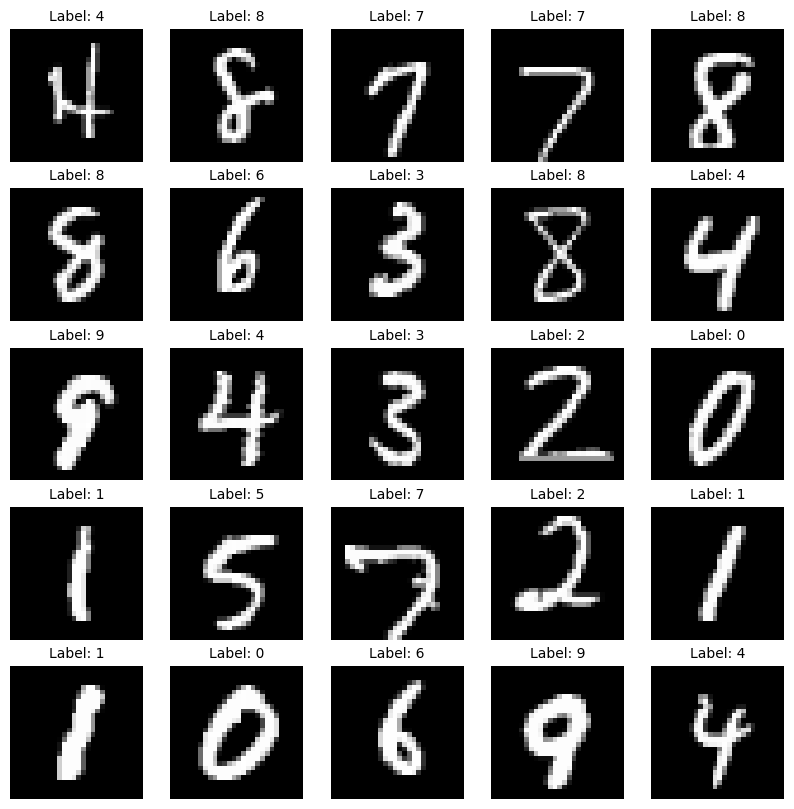

In [76]:
# TODO: Visualise une grille 5x5 d'images aléatoires avec leurs labels
#
# Hint:
#   - plt.figure(figsize=(10, 10))
#   - boucle de 1 à 25
#   - plt.subplot(5, 5, i)
#   - plt.imshow(image, cmap='gray')
#   - plt.title(f'Label: {label}', fontsize=10)
#   - plt.axis('off')

# YOUR CODE HERE

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    v = int(np.random.random() * 60000)
    plt.imshow(X_train[v], cmap='gray')
    plt.title(f'Label: {y_train[v]}', fontsize=10)
    plt.axis('off')


array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])

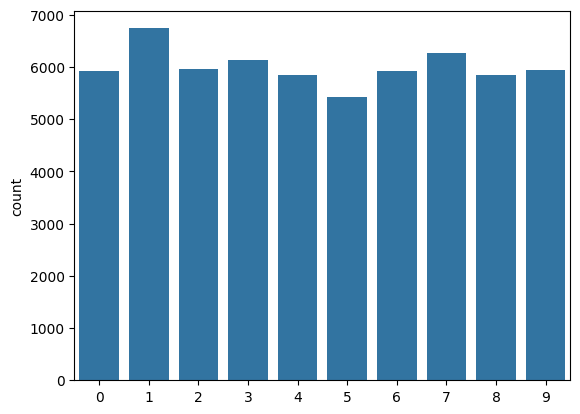

In [25]:
# TODO: Affiche la distribution des classes dans y_train
# Question à se poser : le dataset est-il équilibré ?
# (environ le même nombre d'exemples pour chaque chiffre ?)
#
# Hint: plt.hist(y_train, bins=range(11), align='left', rwidth=0.8)
#       ou sns.countplot(x=y_train)

# YOUR CODE HERE

sns.countplot(x=y_train)

"""
Le dataset est plutôt équilibré
"""

# Affiche aussi le nombre exact par classe
# Hint: np.bincount(y_train)

np.bincount(y_train)

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0
  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0
  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0
  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0   0   0   0   0   0   0   0 

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

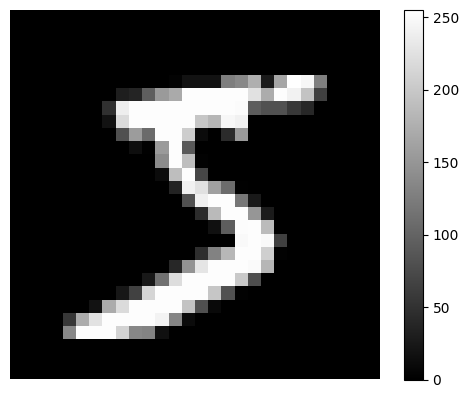

In [78]:
# TODO: Zoom sur une image — affiche les valeurs brutes des pixels (pas juste l'image)
# Hint:
#   - Choisis l'image d'index 0
#   - Affiche-la avec imshow
#   - Affiche le tableau numpy avec print(X_train[0]) — que vois-tu ?
#   - BONUS: utilise plt.colorbar() pour voir l'échelle des valeurs

# YOUR CODE HERE

img = X_train[0]

for i in range(28):
    print(" ".join([(3 - len(str(e))) * " " + str(e) for e in img[i]]))
plt.imshow(img, cmap='gray')
plt.colorbar()
plt.axis('off')

---
## Module 2 — Preprocessing

**Objectif** : Préparer les données pour les algorithmes de ML/DL.

**Concepts** :
- **Normalisation** : ramener les pixels de [0, 255] à [0, 1] → stabilise l'entraînement
- **Flatten / Reshape** : différents modèles ont besoin de formats différents  
  - Régression logistique & MLP : vecteur 1D `(784,)`
  - CNN : image 2D avec canal `(28, 28, 1)`
- **One-hot encoding** : transformer un label entier en vecteur binaire  
  ex: `3` → `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`

Avant normalisation : min=0, max=255
Après normalisation : min=0.00, max=1.00


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

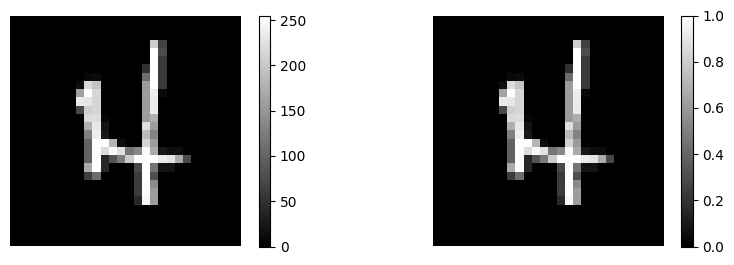

In [5]:
# TODO: Normalise les images — divise par 255.0 pour avoir des valeurs entre 0 et 1
# Hint: X_train_norm = X_train / 255.0
# Pourquoi ? Les réseaux de neurones convergent beaucoup mieux sur des valeurs proches de 0.

# YOUR CODE HERE
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print(f'Avant normalisation : min={X_train.min()}, max={X_train.max()}')
print(f'Après normalisation : min={X_train_norm.min():.2f}, max={X_train_norm.max():.2f}')

v=int(np.random.random()*60000)
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(X_train[v], cmap='gray')
plt.colorbar()
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(X_train_norm[v], cmap='gray')
plt.colorbar()
plt.axis('off')


In [ ]:
# TODO: Flatten — transforme chaque image 28x28 en vecteur de 784 valeurs
# Une image (28, 28) devient un vecteur (784,)
# L'ensemble X_train (60000, 28, 28) devient (60000, 784)
#
# Hint: X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
# Le -1 dit à numpy de calculer automatiquement la deuxième dimension (28*28=784)

# YOUR CODE HERE
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_flat = X_test_norm.reshape(len(X_test_norm), -1)

print(f'X_train_flat shape : {X_train_flat.shape}')  # attendu: (60000, 784)
print(f'X_test_flat shape  : {X_test_flat.shape}')   # attendu: (10000, 784)

X_train_flat shape : (60000, 784)
X_test_flat shape  : (10000, 784)


In [7]:
# TODO: Reshape pour CNN — ajoute une dimension de canal (grayscale = 1 canal)
# (60000, 28, 28) → (60000, 28, 28, 1)
#
# Hint: X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
# ou   X_train_cnn = X_train_norm[..., np.newaxis]

# YOUR CODE HERE
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

print(f'X_train_cnn shape : {X_train_cnn.shape}')  # attendu: (60000, 28, 28, 1)

X_train_cnn shape : (60000, 28, 28, 1)


In [8]:
# TODO: One-hot encoding des labels pour les réseaux de neurones
# ex: 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# Pourquoi ? La fonction de perte 'categorical_crossentropy' attend ce format.
#
# Hint: keras.utils.to_categorical(y_train, num_classes=10)

# YOUR CODE HERE
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=10)
y_test_ohe = keras.utils.to_categorical(y_test, num_classes=10)

print(f'y_train_ohe shape : {y_train_ohe.shape}')  # attendu: (60000, 10)
print(f'Exemple — label {y_train[0]} → {y_train_ohe[0]}')

y_train_ohe shape : (60000, 10)
Exemple — label 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


---
## Module 3 — Baseline : Régression Logistique

**Objectif** : Établir un score de référence avant d'utiliser du deep learning.

**Pourquoi une baseline ?**  
Toujours partir d'un modèle simple. Si ton réseau de neurones ne fait pas mieux que la régression logistique, c'est qu'il y a un problème.

**Concepts** :
- **Régression logistique multiclasse** : generalisation de la régression binaire à 10 classes
- **Accuracy** : % de bonnes prédictions
- **Precision / Recall / F1** : métriques par classe (utiles si le dataset est déséquilibré)
- **Confusion matrix** : visualise quelles classes sont confondues entre elles

> **Données utilisées** : `X_train_flat`, `X_test_flat`, `y_train`, `y_test`

In [85]:
# TODO: Entraîne une régression logistique sur les données flatten+normalisées
#
# Hint:
#   model_lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
#   model_lr.fit(X_train_flat, y_train)
#
# max_iter=1000 : nombre max d'itérations pour converger
# n_jobs=-1     : utilise tous les coeurs CPU disponibles (plus rapide)
# Attention     : peut prendre 1-2 minutes sur CPU

print('Entraînement de la régression logistique...')

# YOUR CODE HERE
model_lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
model_lr.fit(X_train_flat, y_train)

print('Entraînement terminé !')

Entraînement de la régression logistique...


/home/alban/.conda/envs/mnist/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Entraînement terminé !


In [135]:
# TODO: Évalue le modèle sur le test set
#
# Étape 1: Prédit les labels avec model_lr.predict(X_test_flat)
# Étape 2: Calcule l'accuracy avec accuracy_score(y_test, y_pred_lr)
# Étape 3: Affiche le classification_report(y_test, y_pred_lr)
# Étape 4: Affiche la confusion matrix (voir code de visualisation plus bas)

# YOUR CODE HERE
y_pred_lr = model_lr.predict(X_test_flat)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy (Régression Logistique) : {acc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr))

Accuracy (Régression Logistique) : 0.9256

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.87      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



In [ ]:
# Visualisation de la confusion matrix
# (code fourni — comprends ce que tu lis !)
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Prédit')
    plt.ylabel('Vrai')
    plt.title(title)
    plt.show()

# TODO: Appelle plot_confusion_matrix avec les prédictions de la régression logistique
# Que remarques-tu ? Quels chiffres sont souvent confondus entre eux ?

# YOUR CODE HERE

plot_confusion_matrix(y_test, y_pred_lr)

# RÉFLEXION (écris tes observations ici) :
# - Quels chiffres sont le plus souvent confondus ?
# - Pourquoi à ton avis ?

---
## Module 4 — MLP : Réseau de Neurones Dense

**Objectif** : Construire et entraîner ton premier réseau de neurones.

**Concepts** :
- **MLP** (Multi-Layer Perceptron) : réseau entièrement connecté (dense)
- **Neurone artificiel** : somme pondérée des entrées + activation non-linéaire
- **Activation ReLU** : `f(x) = max(0, x)` — la plus utilisée en pratique
- **Activation Softmax** : convertit les scores en probabilités (somme = 1) — couche de sortie multiclasse
- **Backpropagation** : l'algorithme qui ajuste les poids pour réduire l'erreur
- **Adam** : optimiseur adaptatif, très bon par défaut
- **Batch** : sous-ensemble des données traité à chaque étape de gradient
- **Epoch** : une passe complète sur tout le dataset d'entraînement

**Architecture** :
```
Input (784)  →  Dense(128, relu)  →  Dense(64, relu)  →  Dense(10, softmax)
```

> **Données utilisées** : `X_train_flat`, `X_test_flat`, `y_train_ohe`, `y_test_ohe`

In [114]:
# TODO: Construis le MLP avec l'API Sequential de Keras
#
# Hint:
#   model_mlp = keras.Sequential([
#       layers.Dense(128, activation='relu', input_shape=(784,)),
#       layers.Dense(64, activation='relu'),
#       layers.Dense(10, activation='softmax'),   # 10 sorties = 10 classes
#   ])
#
# Pourquoi softmax en sortie ?  → transforme les scores en probabilités (somme = 1)
# Pourquoi 10 neurones ?        → un par classe (0 à 9)

# YOUR CODE HERE
model_mlp = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

model_mlp.summary()
# Observe : combien de paramètres (poids) au total ? Compare avec la régression logistique.

/home/alban/.conda/envs/mnist/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
# TODO: Compile le modèle (définit comment l'entraîner)
#
# Hint:
#   model_mlp.compile(
#       optimizer='adam',
#       loss='categorical_crossentropy',   # loss standard pour classification multiclasse one-hot
#       metrics=['accuracy']
#   )
#
# optimizer  : algorithme de descente de gradient (Adam = très bon par défaut)
# loss       : mesure à minimiser — categorical_crossentropy pour labels one-hot
# metrics    : ce qu'on affiche pendant l'entraînement (pas ce qui est optimisé)

# YOUR CODE HERE
model_mlp.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [121]:
# TODO: Entraîne le MLP
#
# Hint:
#   history_mlp = model_mlp.fit(
#       X_train_flat, y_train_ohe,
#       epochs=20,
#       batch_size=128,
#       validation_split=0.1,   # 10% du train pour la validation (mesure l'overfitting)
#       verbose=1
#   )
#
# epochs=20         : 20 passes sur les données
# batch_size=128    : 128 exemples à la fois avant de mettre à jour les poids
# validation_split  : réserve 10% pour mesurer si le modèle généralise bien

# YOUR CODE HERE
history_mlp = model_mlp.fit(
    X_train_flat, y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20


I0000 00:00:1773066824.154272   31382 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_117835__.17


385/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8083 - loss: 0.6777

I0000 00:00:1773066825.741250   31381 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_117835__.17


422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8995 - loss: 0.3556 - val_accuracy: 0.9612 - val_loss: 0.1388
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9568 - loss: 0.1464 - val_accuracy: 0.9698 - val_loss: 0.1040
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9700 - loss: 0.1013 - val_accuracy: 0.9725 - val_loss: 0.0930
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9778 - loss: 0.0760 - val_accuracy: 0.9748 - val_loss: 0.0882
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9831 - loss: 0.0597 - val_accuracy: 0.9755 - val_loss: 0.0858
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9873 - loss: 0.0469 - val_accuracy: 0.9762 - val_loss: 0.0879
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9900 - loss: 0.0369 - val_accuracy: 0.9737 - val_loss: 0.0959
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9922 - loss: 0.0293 - val_accuracy: 0.9718 - val_

In [ ]:
# Fonction utilitaire : visualise les courbes d'entraînement
# (code fourni — lis-le pour comprendre ce qu'il fait)
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# TODO: Appelle plot_history(history_mlp, title='MLP')
# Ce que tu cherches à observer :
#   - La val_accuracy monte-t-elle aussi bien que la train_accuracy ?
#   - Si val_loss remonte alors que train_loss descend → OVERFITTING

# YOUR CODE HERE
plot_history(history_mlp, title='MLP')


In [131]:
# TODO: Évalue le MLP sur le test set
#
# Hint:
#   loss, acc = model_mlp.evaluate(X_test_flat, y_test_ohe, verbose=0)
#   print(f'Test accuracy (MLP): {acc:.4f}')
#
# Compare avec la régression logistique — le MLP fait-il mieux ?

# YOUR CODE HERE
loss, acc_mlp = model_mlp.evaluate(X_test_flat, y_test_ohe, verbose=0)
print(f'Test accuracy (MLP): {acc_mlp:.4f}')


Test accuracy (MLP): 0.9772


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step
Accuracy (MLP) : 0.9772

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.94      0.97       892
           6       0.98      0.99      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



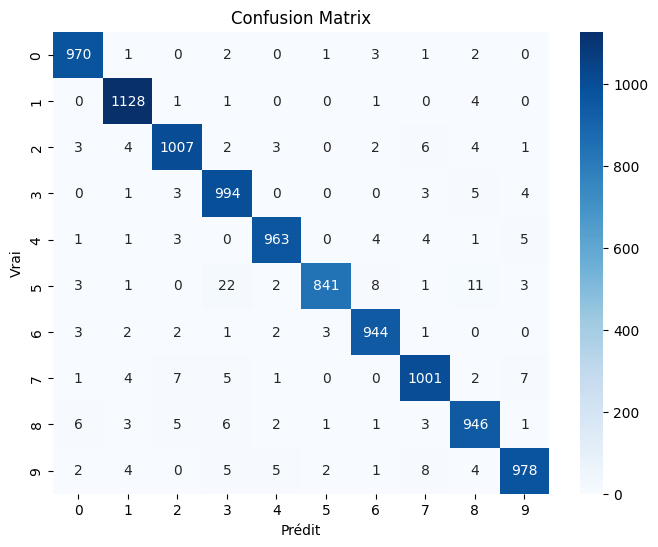

In [125]:
# BONUS: affiche aussi la confusion matrix du MLP
# Hint: model_mlp.predict(X_test_flat) → probs, np.argmax(probs, axis=1) → classes

probs = model_mlp.predict(X_test_flat)

y_pred_mlp = np.argmax(probs, axis=1)

print(f'Accuracy (MLP) : {accuracy_score(y_test, y_pred_mlp):.4f}')
print()
print(classification_report(y_test, y_pred_mlp))

plot_confusion_matrix(y_test, y_pred_mlp)

---
## Module 5 — CNN : Réseau Convolutif

**Objectif** : Exploiter la structure spatiale des images avec des convolutions.

**Pourquoi le CNN ?**  
Le MLP traite chaque pixel indépendamment. Le CNN apprend des **filtres locaux** qui détectent des patterns (bords, courbes, formes) en exploitant la structure 2D de l'image.

**Concepts** :
- **Conv2D** : applique des filtres (kernels) sur l'image → crée des feature maps
  - Chaque filtre détecte un pattern (bord horizontal, coin, etc.)
  - Paramètre `filters` = nombre de filtres ; `kernel_size` = taille du filtre (ex: 3×3)
- **MaxPooling2D** : réduit la résolution des feature maps (sous-échantillonnage)
  - Garde le max dans chaque fenêtre → rend le modèle robuste aux petits décalages
- **Flatten** : aplatie les feature maps en vecteur 1D pour les couches denses
- **Partage de poids** : le même filtre est appliqué partout = beaucoup moins de paramètres qu'un MLP

**Architecture** :
```
Input (28,28,1)
  → Conv2D(32, 3×3, relu)  → MaxPool(2×2)     # feature maps: 32×13×13
  → Conv2D(64, 3×3, relu)  → MaxPool(2×2)     # feature maps: 64×5×5
  → Flatten                                    # vecteur: 1600
  → Dense(64, relu)
  → Dense(10, softmax)
```

> **Données utilisées** : `X_train_cnn`, `X_test_cnn`, `y_train_ohe`, `y_test_ohe`

In [126]:
# TODO: Construis le CNN selon l'architecture décrite ci-dessus
#
# Hint:
#   model_cnn = keras.Sequential([
#       layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
#       layers.MaxPooling2D((2, 2)),
#       layers.Conv2D(64, (3, 3), activation='relu'),
#       layers.MaxPooling2D((2, 2)),
#       layers.Flatten(),
#       layers.Dense(64, activation='relu'),
#       layers.Dense(10, activation='softmax'),
#   ])
#
# Observe le résumé : combien de paramètres comparé au MLP ?
# Pourquoi moins de paramètres mais de meilleures performances ?

# YOUR CODE HERE
model_cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])

model_cnn.summary()

/home/alban/.conda/envs/mnist/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
# TODO: Compile et entraîne le CNN
# Mêmes hyperparamètres que le MLP (adam, categorical_crossentropy, accuracy)
# epochs=15, batch_size=128, validation_split=0.1
#
# Note: le CNN est plus lent à entraîner que le MLP (plus de calculs par image)
# mais il converge mieux et généralise mieux.

# YOUR CODE HERE — compile

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Entraînement du CNN...')

# YOUR CODE HERE — fit
history_cnn = model_cnn.fit(
    X_train_cnn, y_train_ohe,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Entraînement du CNN...
Epoch 1/20


I0000 00:00:1773066900.519914   31383 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163705__.34


421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8359 - loss: 0.5678

I0000 00:00:1773066903.365773   31381 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_163705__.34


422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9272 - loss: 0.2500 - val_accuracy: 0.9803 - val_loss: 0.0702
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9778 - loss: 0.0717 - val_accuracy: 0.9828 - val_loss: 0.0572
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9846 - loss: 0.0498 - val_accuracy: 0.9877 - val_loss: 0.0461
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9880 - loss: 0.0383 - val_accuracy: 0.9883 - val_loss: 0.0420
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9905 - loss: 0.0304 - val_accuracy: 0.9888 - val_loss: 0.0389
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9924 - loss: 0.0246 - val_accuracy: 0.9892 - val_loss: 0.0397
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9939 - loss: 0.0204 - val_accuracy: 0.9897 - val_loss: 0.0436
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9949 - loss: 0.0177 - val_accuracy: 0.9895 - val_

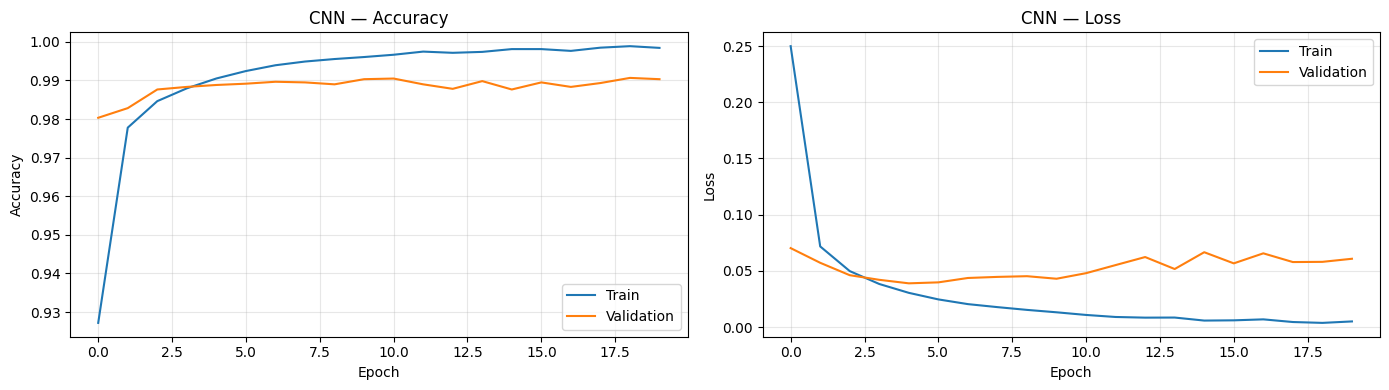

Test accuracy (CNN): 0.9903


In [132]:
# TODO: Évalue le CNN et compare avec les modèles précédents
# Affiche les courbes d'entraînement avec plot_history(history_cnn, 'CNN')
# Évalue avec model_cnn.evaluate(X_test_cnn, y_test_ohe)

# YOUR CODE HERE
plot_history(history_cnn, 'CNN')


loss, acc_cnn = model_cnn.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print(f'Test accuracy (CNN): {acc_cnn:.4f}')


(0.9, 1.0)

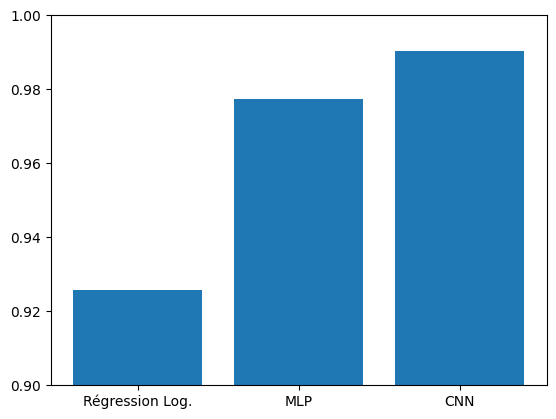

In [133]:
# TODO: Comparaison des 3 modèles
# Crée un bar chart comparant l'accuracy sur le test set de:
#   - Régression Logistique
#   - MLP
#   - CNN
#
# Hint:
#   resultats = {'Régression Log.': acc_lr, 'MLP': acc_mlp, 'CNN': acc_cnn}
#   plt.bar(resultats.keys(), resultats.values())
#   plt.ylim(0.9, 1.0)

# YOUR CODE HERE
resultats = {'Régression Log.': acc_lr, 'MLP': acc_mlp, 'CNN': acc_cnn}
plt.bar(resultats.keys(), resultats.values())
plt.ylim(0.9, 1.0)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy (MLP) : 0.9903

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



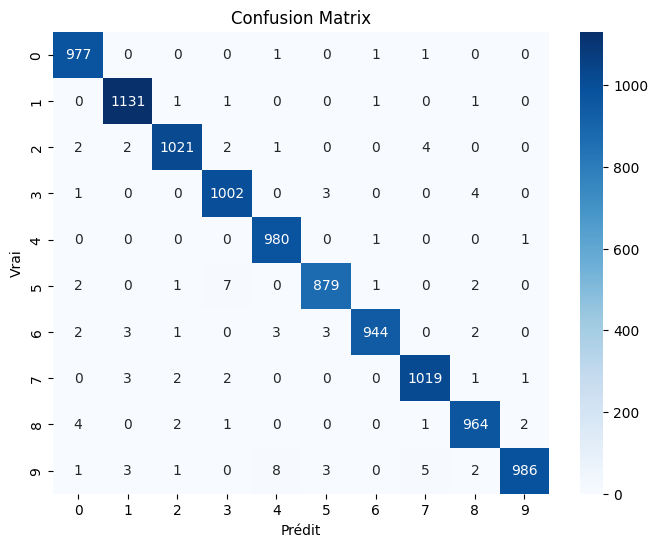

In [ ]:
# BONUS: affiche aussi la confusion matrix du CNN

probs = model_cnn.predict(X_test_cnn)

y_pred_cnn = np.argmax(probs, axis=1)

print(f'Accuracy (CNN) : {accuracy_score(y_test, y_pred_cnn):.4f}')
print()
print(classification_report(y_test, y_pred_cnn))

plot_confusion_matrix(y_test, y_pred_cnn)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


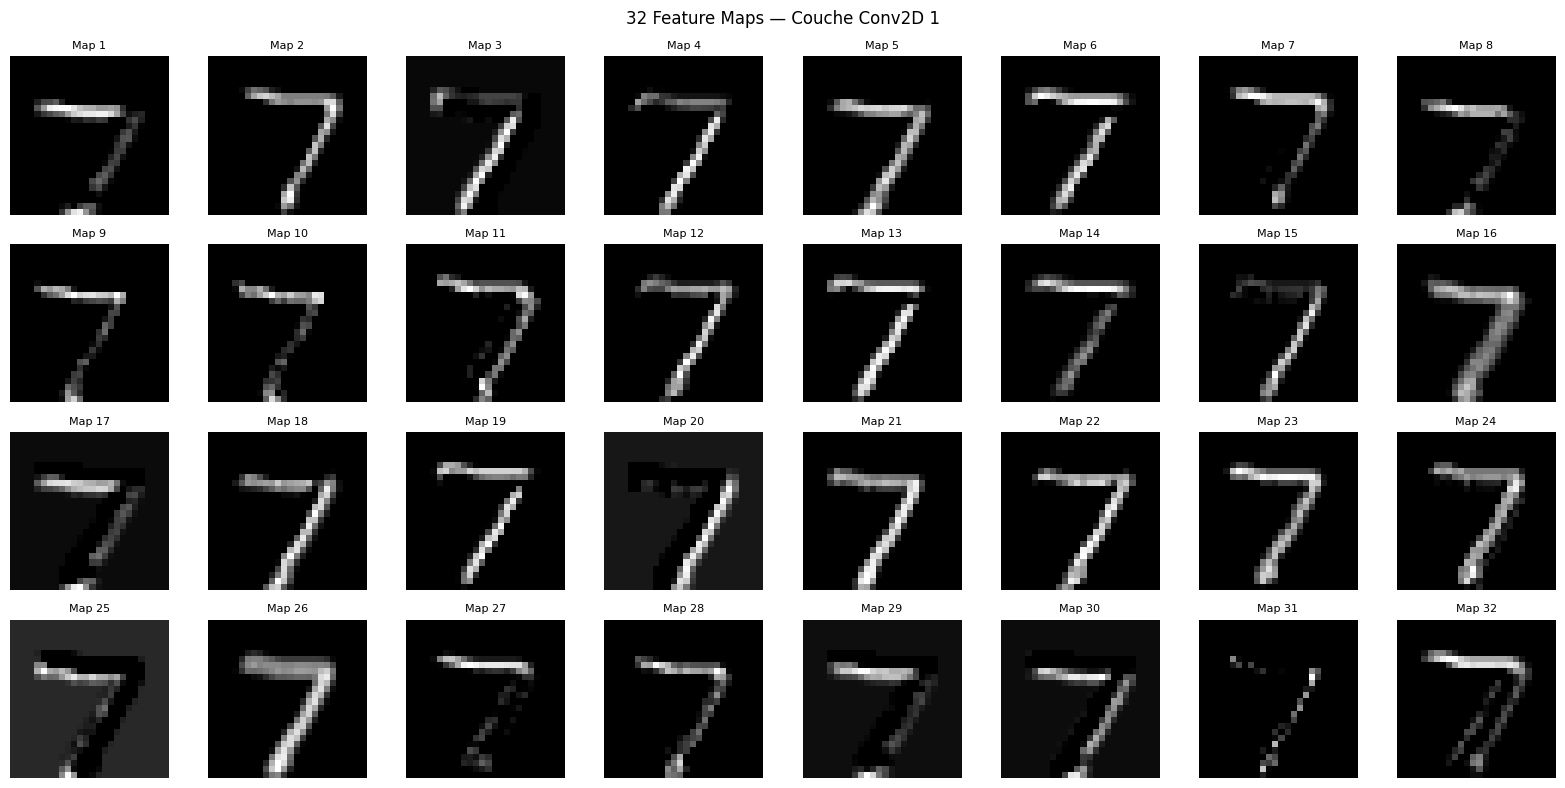

In [141]:
# BONUS — Visualise les feature maps du CNN
# Que "voit" le réseau dans une image ?
#
# Hint: crée un modèle intermédiaire qui sort la première couche Conv2D
#   feature_model = keras.Model(inputs=model_cnn.inputs,
#                               outputs=model_cnn.layers[0].output)
#   feature_maps = feature_model.predict(X_test_cnn[:1])  # une image
#   # feature_maps shape: (1, 26, 26, 32) — 32 feature maps de 26x26
#   # Affiche les 32 feature maps dans une grille 4x8

# YOUR CODE HERE (optionnel)
feature_model = keras.Model(inputs=model_cnn.inputs, outputs=model_cnn.layers[0].output)
feature_maps = feature_model.predict(X_test_cnn[:1])  # shape: (1, 26, 26, 32)

plt.figure(figsize=(16, 8))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='gray')
    plt.title(f'Map {i+1}', fontsize=8)
    plt.axis('off')
plt.suptitle('32 Feature Maps — Couche Conv2D 1')
plt.tight_layout()
plt.show()


---
## Module 6 — Amélioration du Modèle

**Objectif** : Pousser les performances et rendre le modèle plus robuste.

**Techniques** :
- **Data Augmentation** : générer de nouvelles images synthétiques (rotation, zoom, translation)  
  → le modèle voit plus de variété → meilleure généralisation
- **Dropout** : désactiver aléatoirement x% des neurones pendant l'entraînement  
  → empêche l'overfitting → `layers.Dropout(0.3)`
- **BatchNormalization** : normalise les activations à chaque couche  
  → stabilise et accélère l'entraînement → `layers.BatchNormalization()`
- **EarlyStopping** : stoppe l'entraînement quand le modèle ne s'améliore plus  
  → évite l'overfitting et économise du temps
- **ModelCheckpoint** : sauvegarde automatiquement la meilleure version du modèle

> **Rappel Overfitting** : val_loss remonte alors que train_loss descend  
> → le modèle "mémorise" les données d'entraînement au lieu de généraliser

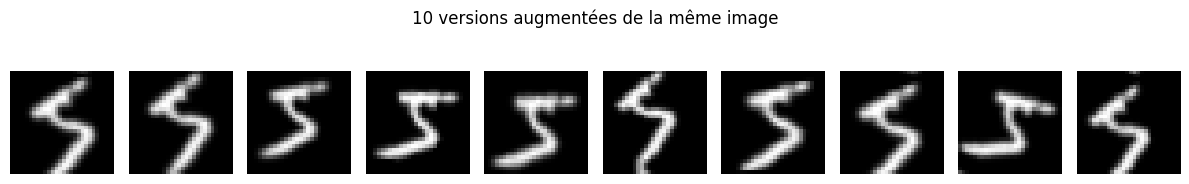

In [9]:
# Data Augmentation — génère des variations des images d'entraînement
# Ce bloc de transformation sera intégré dans le modèle (appliqué uniquement au train)

data_augmentation = keras.Sequential([
    # TODO: Ajoute des transformations d'augmentation
    # Hint:
    #   layers.RandomRotation(0.1),           # rotation aléatoire ±10%
    #   layers.RandomZoom(0.1),               # zoom aléatoire ±10%
    #   layers.RandomTranslation(0.1, 0.1),   # translation aléatoire ±10%
    #
    # Attention: ne pas exagérer — trop d'augmentation nuit aussi
    # YOUR CODE HERE
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='data_augmentation')

# Visualise l'effet de l'augmentation sur une image
sample_img = X_train_cnn[:1]
plt.figure(figsize=(12, 2))
for i in range(10):
    augmented = data_augmentation(sample_img, training=True)
    plt.subplot(1, 10, i + 1)
    plt.imshow(augmented[0, :, :, 0], cmap='gray')
    plt.axis('off')
plt.suptitle("10 versions augmentées de la même image", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# TODO: Construis CNN v2 — plus robuste avec Dropout et BatchNorm
#
# Architecture suggérée:
#   data_augmentation  (couche d'augmentation, active only at training)
#   Conv2D(32, 3x3, relu) → BatchNormalization() → MaxPooling(2,2)
#   Conv2D(64, 3x3, relu) → BatchNormalization() → MaxPooling(2,2)
#   Flatten()
#   Dense(128, relu) → Dropout(0.3)
#   Dense(10, softmax)
#
# Hint: commence le modèle avec layers.Input(shape=(28,28,1)) puis data_augmentation

model_cnn_v2 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    # YOUR CODE HERE
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax'),
])

model_cnn_v2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

In [11]:
# TODO: Définis les callbacks
#
# Hint:
#   callbacks = [
#       keras.callbacks.EarlyStopping(
#           monitor='val_loss',
#           patience=5,                    # stoppe si pas d'amélioration pendant 5 epochs
#           restore_best_weights=True      # recharge les poids du meilleur epoch
#       ),
#       keras.callbacks.ModelCheckpoint(
#           'best_cnn_v2.keras',
#           monitor='val_accuracy',
#           save_best_only=True            # ne sauvegarde que si c'est le meilleur
#       ),
#   ]

# YOUR CODE HERE
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        'best_cnn_v2.keras',
        monitor='val_accuracy',
        save_best_only=True
    ),
]

# Compile le modèle
# YOUR CODE HERE

model_cnn_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Entraînement CNN v2 avec augmentation...')
# TODO: Entraîne avec epochs=30 (EarlyStopping s'occupera de stopper avant si nécessaire)
# YOUR CODE HERE
history_cnn_v2 = model_cnn_v2.fit(
    X_train_cnn, y_train_ohe,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
    callbacks=callbacks
)

Entraînement CNN v2 avec augmentation...
Epoch 1/50


W0000 00:00:1773149936.359801   19851 cpu_allocator_impl.cc:82] Allocation of 169344000 exceeds 10% of free system memory.
W0000 00:00:1773149936.597381   19851 cpu_allocator_impl.cc:82] Allocation of 169344000 exceeds 10% of free system memory.
I0000 00:00:1773149938.838172   24818 cuda_dnn.cc:461] Loaded cuDNN version 92000


422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8309 - loss: 0.5384 - val_accuracy: 0.7040 - val_loss: 0.8150
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9386 - loss: 0.1973 - val_accuracy: 0.9752 - val_loss: 0.0816
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9524 - loss: 0.1547 - val_accuracy: 0.9810 - val_loss: 0.0661
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9606 - loss: 0.1305 - val_accuracy: 0.9790 - val_loss: 0.0798
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9654 - loss: 0.1142 - val_accuracy: 0.9830 - val_loss: 0.0615
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9679 - loss: 0.1078 - val_accuracy: 0.9788 - val_loss: 0.0790
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9706 - loss: 0.0975 - val_accuracy: 0.9723 - val_loss: 0.0905
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9719 - loss: 0.0936 - val_accuracy: 0.9865 

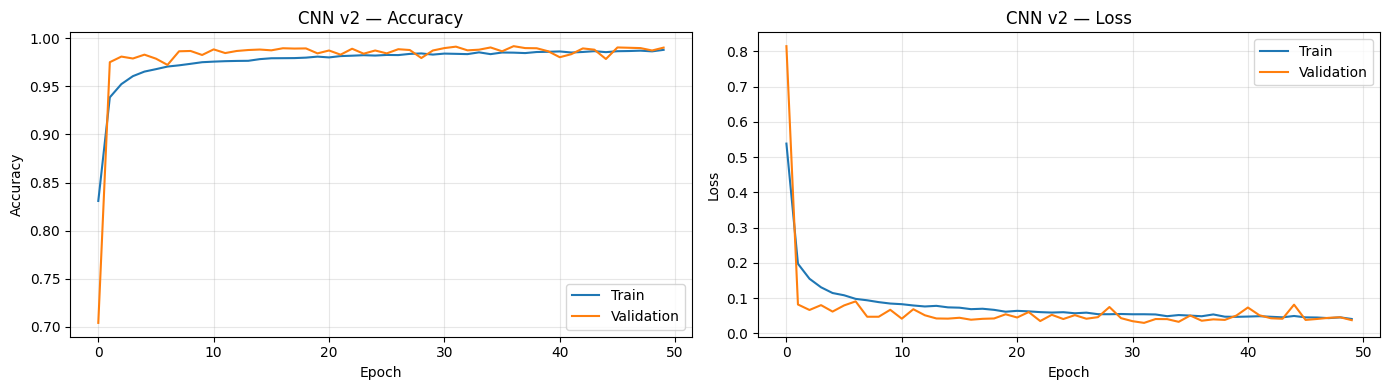

Test accuracy (CNN v2): 0.9903


In [14]:
plot_history(history_cnn_v2, 'CNN v2')

loss, acc_cnn_v2 = model_cnn_v2.evaluate(X_test_cnn, y_test_ohe, verbose=0)
print(f'Test accuracy (CNN v2): {acc_cnn_v2:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Accuracy (CNN v2) : 0.9903

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       0.99      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.97      0.99      0.98       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



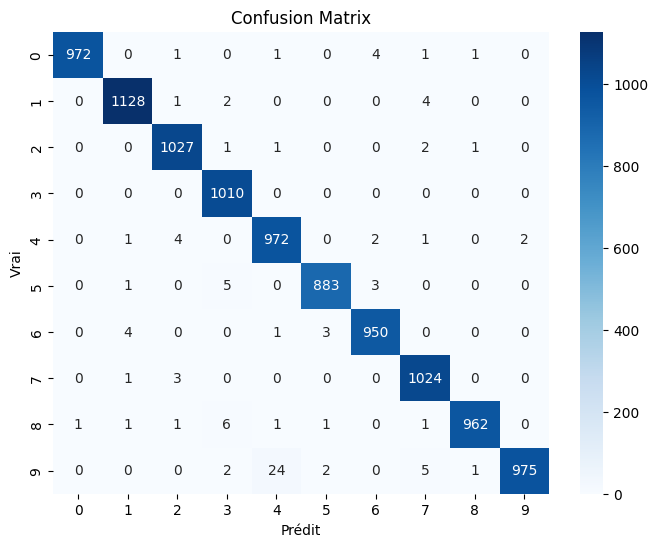

In [17]:
# BONUS: affiche aussi la confusion matrix du CNN v2

probs = model_cnn_v2.predict(X_test_cnn)

y_pred_cnn_v2 = np.argmax(probs, axis=1)

print(f'Accuracy (CNN v2) : {accuracy_score(y_test, y_pred_cnn_v2):.4f}')
print()
print(classification_report(y_test, y_pred_cnn_v2))

plot_confusion_matrix(y_test, y_pred_cnn_v2)

(0.9, 1.0)

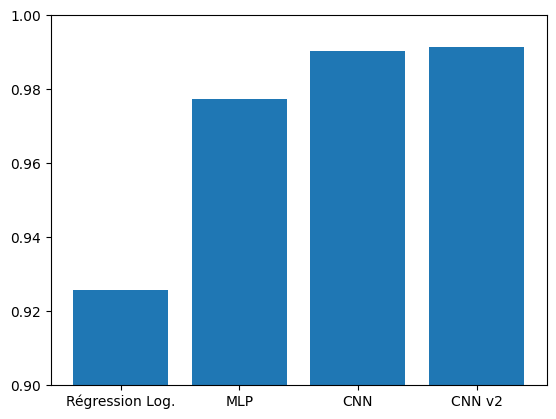

In [206]:
# TODO: Comparaison finale de tous les modèles
# Affiche les accuracies de: Régression Log. / MLP / CNN v1 / CNN v2
# Quel modèle gagne ? L'amélioration valait-elle le temps d'entraînement supplémentaire ?

resultats = {'Régression Log.': acc_lr, 'MLP': acc_mlp, 'CNN': acc_cnn, 'CNN v2': acc_cnn_v2}
plt.bar(resultats.keys(), resultats.values())
plt.ylim(0.9, 1.0)

---
## Module 7 — Démo : Pipeline Complet

**Objectif** : Mettre le modèle en production — de l'image brute à la prédiction.

**Ce que tu vas faire** :
1. Sauvegarder et recharger ton meilleur modèle
2. Écrire une fonction d'inférence `predict_digit(image)`
3. Analyser les erreurs — comprendre où le modèle rate
4. BONUS : prédire ton propre chiffre dessiné à la main

> **Inférence** : utiliser un modèle entraîné pour faire une prédiction sur une nouvelle donnée.

In [19]:
# Sauvegarde ton meilleur modèle
# TODO: remplace model_cnn_v2 par ton meilleur modèle si différent

# YOUR CODE HERE
model_cnn.save('digit_recognizer.keras')
print('Modèle sauvegardé dans digit_recognizer.keras')

# Recharge le modèle (simule une vraie utilisation en production)
loaded_model = keras.models.load_model('best_cnn_v2.keras')
print('Modèle rechargé avec succès !')
loaded_model.summary()

Modèle rechargé avec succès !


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,872 (2.58 MB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 450,454 (1.72 MB)

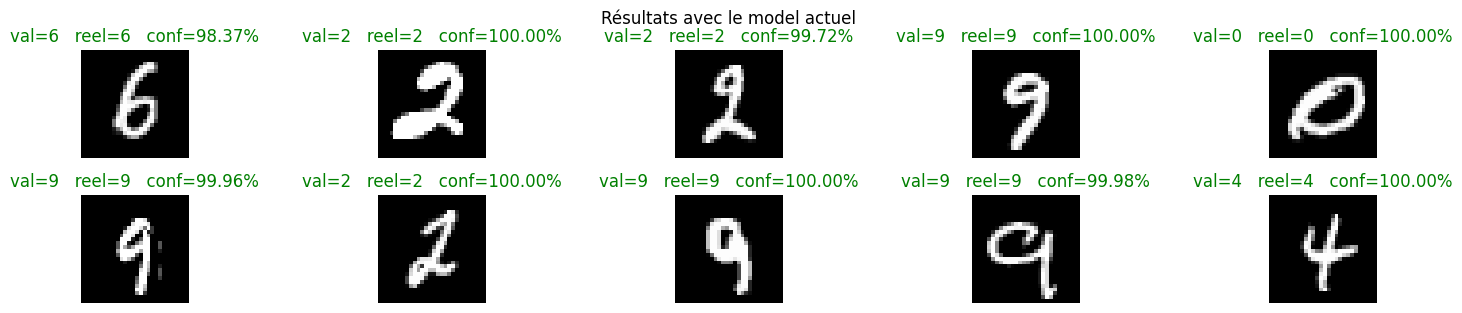

In [21]:
# Fonction d'inférence complète
# (code fourni — comprends chaque étape du pipeline)

def predict_digit(image_array, model):
    """
    Prédit le chiffre dans une image.

    Args:
        image_array : numpy array (28, 28) avec valeurs 0-255
        model       : modèle Keras entraîné

    Returns:
        predicted_class : int (0-9)
        confidence      : float (0.0-1.0)
        probabilities   : array (10,) — probabilité pour chaque classe
    """
    img = image_array.astype('float32') / 255.0   # normalisation
    img = img.reshape(1, 28, 28, 1)               # reshape pour CNN
    probabilities = model.predict(img, verbose=0)[0]
    predicted_class = int(np.argmax(probabilities))
    confidence = float(probabilities[predicted_class])
    return predicted_class, confidence, probabilities


# TODO: Teste la fonction sur 10 images aléatoires du test set
# Affiche chaque image avec son vrai label et la prédiction (vert=correct, rouge=erreur)
#
# Hint:
#   indices = np.random.randint(0, len(X_test), 10)
#   pour chaque image: appelle predict_digit(X_test[idx], loaded_model)
#   utilise plt.title(color='green' if correct else 'red')

# YOUR CODE HERE
indices = np.random.randint(0, len(X_test), 10)

plt.figure(figsize=(15, 15))

for i in range(len(indices)):
    predicted_class, confidence, probabilities = predict_digit(X_test[indices[i]], loaded_model)
    plt.subplot(10, 5, i + 1)
    plt.imshow(X_test[indices[i]], cmap='gray')
    plt.axis('off')
    correct = predicted_class == int(y_test[indices[i]])
    plt.title(f"val={predicted_class}   reel={y_test[indices[i]]}   conf={confidence*100.0:.2f}%", color='green' if correct else 'red')

plt.suptitle("Résultats avec le model actuel", fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# TODO: Analyse les erreurs — qu'est-ce que le modèle rate ?
#
# Étape 1: Trouve tous les indices mal classifiés dans le test set
#   Hint: np.where(y_pred != y_test)[0]
#
# Étape 2: Affiche une grille 5x5 des 25 premières erreurs
#   Pour chaque erreur: affiche l'image + "Vrai: X — Prédit: Y"
#
# Étape 3: Réflexion — ces erreurs sont-elles "humainement compréhensibles" ?
#   Certaines sont-elles des erreurs que TOI tu ferais aussi ?

# YOUR CODE HERE

errors = []

for i in range(len(X_test)):
    predicted_class, confidence, probabilities = predict_digit(X_test[i], loaded_model)
    if predicted_class != y_test[i]:
        errors.append((X_test[i], y_test[i], predicted_class))

# RÉFLEXION (écris tes observations ici) :
# - Le modèle rate-t-il des chiffres évidents ou des cas ambigus ?
# - Y a-t-il des patterns dans les erreurs ?

99 errors for 10000 test cases (0.9900000000000001% of errors)


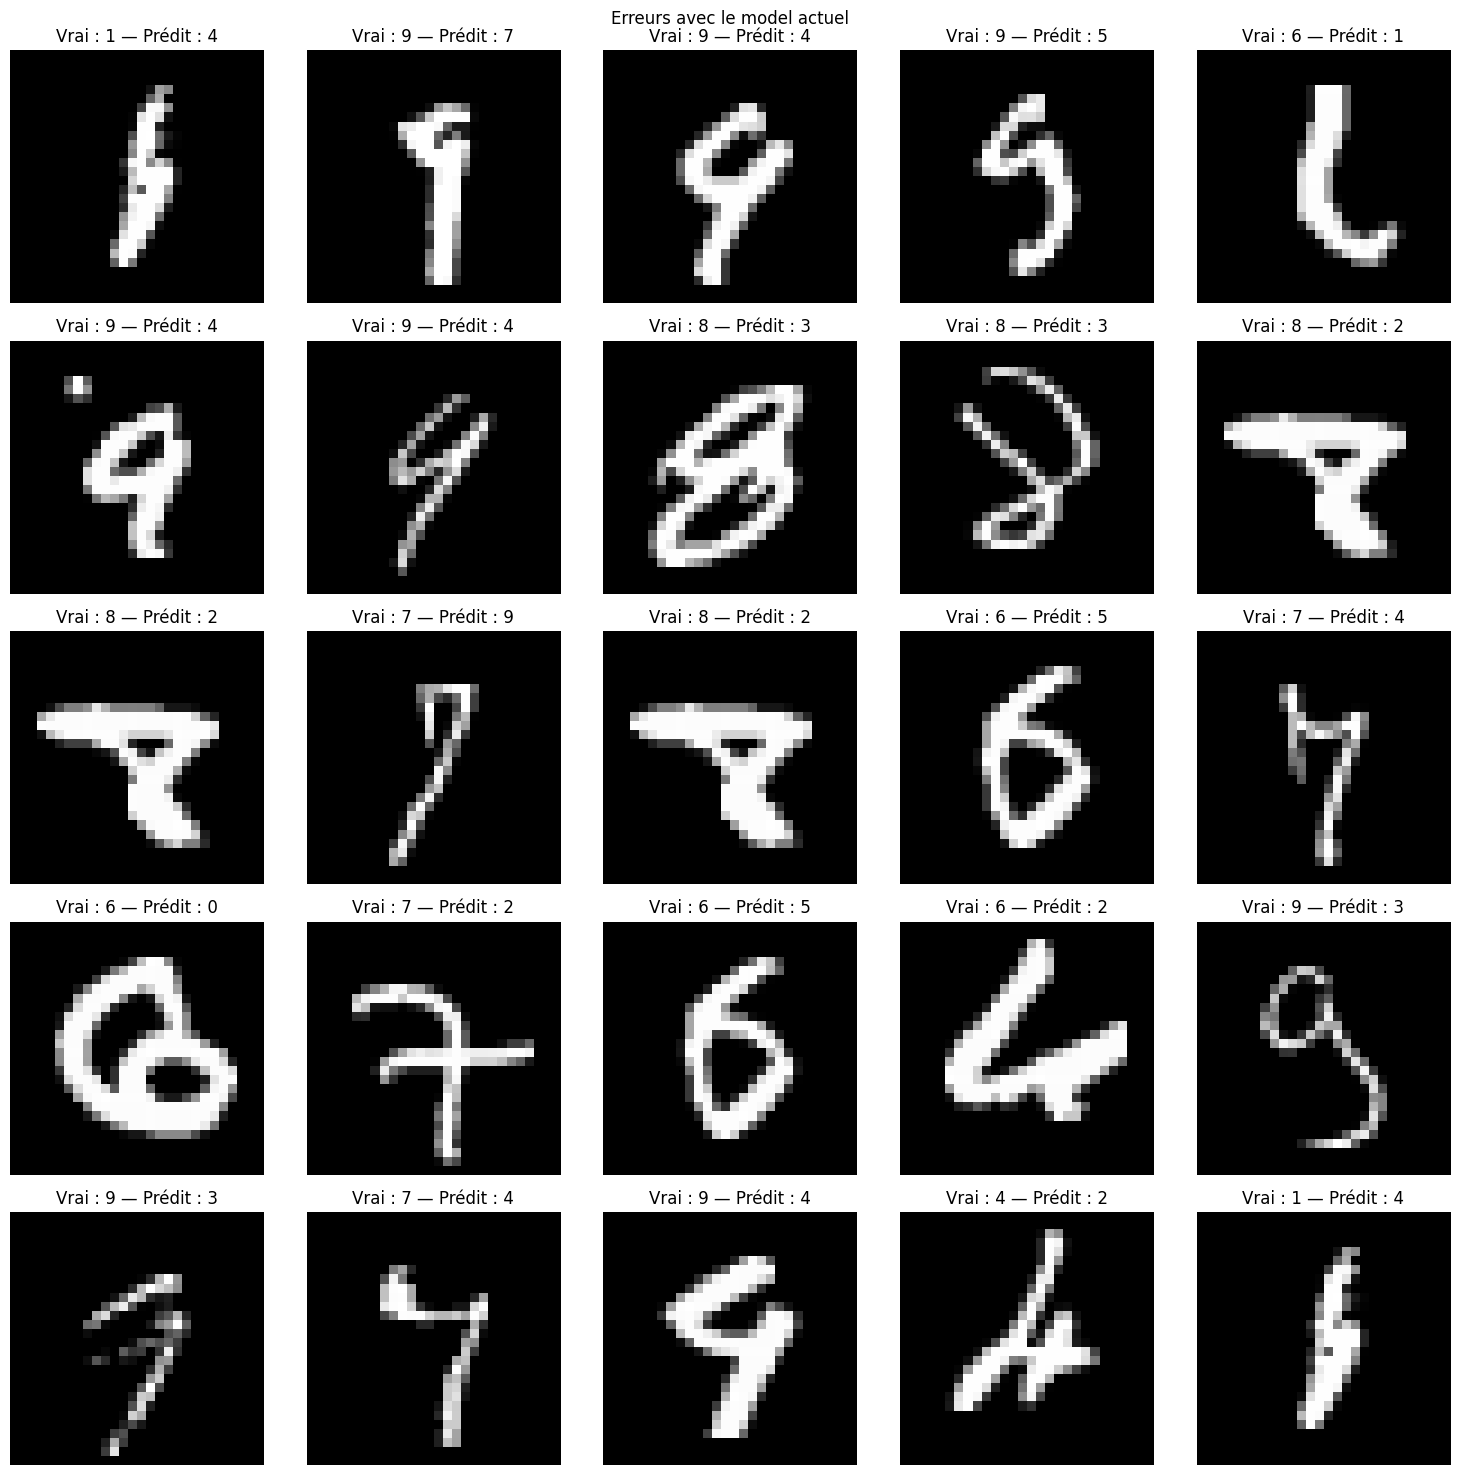

In [23]:
print(f"{len(errors)} errors for {len(X_test)} test cases ({len(errors)/len(X_test)*100}% of errors)")

plt.figure(figsize=(15, 15))

indices = np.random.randint(0, len(errors), 25)

for i in range(len(indices)):
    plt.subplot(5, 5, i + 1)
    plt.imshow(errors[indices[i]][0], cmap='gray')
    plt.axis('off')
    plt.title(f"Vrai : {errors[indices[i]][1]} — Prédit : {errors[indices[i]][2]}")

plt.suptitle("Erreurs avec le model actuel", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# BONUS — Prédis ton propre chiffre écrit à la main !
#
# Option 1 : dessine un chiffre dans un outil (Paint, GIMP, Excalidraw...)
#   - Enregistre en PNG/JPG
#   - Charge l'image avec PIL
#
# Option 2 : utilise un widget interactif dans le notebook (nécessite ipywidgets)

from PIL import Image

def load_custom_digit(filepath):
    """
    Charge une image personnalisée et la prépare pour la prédiction.
    L'image sera redimensionnée en 28x28 niveaux de gris.
    """
    img = Image.open(filepath).convert('L')   # niveaux de gris
    img = img.resize((28, 28), Image.LANCZOS) # redimensionne
    img_array = np.array(img)                 # → numpy array

    # MNIST: fond noir, chiffre blanc
    # Si ton image est fond blanc + chiffre noir, inverse les couleurs:
    # img_array = 255 - img_array

    plt.imshow(img_array, cmap='gray')
    plt.title('Ton image chargée (28x28)')
    plt.axis('off')
    plt.show()
    return img_array

# TODO: Décommente et remplace 'mon_chiffre.png' par le chemin de ton image
# img_array = load_custom_digit('mon_chiffre.png')
# pred, conf, probs = predict_digit(img_array, loaded_model)
# print(f'Chiffre prédit : {pred} ({conf:.0%} de confiance)')
# plt.bar(range(10), probs)
# plt.xlabel('Chiffre')
# plt.ylabel('Probabilité')
# plt.title(f'Distribution softmax — Prédit: {pred}')
# plt.show()

---
## Récapitulatif — Ce que tu as appris

| Concept | Où |
|---------|----|
| Exploration et visualisation de données | Module 1 |
| Normalisation, reshape, one-hot encoding | Module 2 |
| Régression logistique, accuracy, confusion matrix | Module 3 |
| Réseau de neurones dense (MLP), backpropagation | Module 4 |
| Convolutions, feature maps, MaxPooling | Module 5 |
| Data augmentation, Dropout, EarlyStopping | Module 6 |
| Pipeline d'inférence, analyse des erreurs | Module 7 |

---

### Résultats typiques attendus

| Modèle | Test Accuracy (typique) |
|--------|------------------------|
| Régression Logistique | ~92% |
| MLP (2 couches denses) | ~97-98% |
| CNN simple | ~99% |
| CNN + augmentation + dropout | ~99.2-99.4% |
| État de l'art (2024) | ~99.8% |

---

### Pour aller plus loin

Si tu veux continuer après avoir terminé ce cours :

1. **Autres datasets** : Fashion-MNIST, CIFAR-10 (images couleur), EMNIST (lettres)
2. **Architectures avancées** : ResNet, EfficientNet — la même idée, bien plus profonde
3. **Transfer Learning** : utiliser un modèle pré-entraîné sur ImageNet comme point de départ
4. **Déploiement** : exposer ton modèle via une API Flask/FastAPI, le convertir en TensorFlow Lite pour mobile
5. **Explainabilité** : Grad-CAM — visualise ce que le CNN regarde pour décider

---

### Notes personnelles

*(Utilise cet espace pour noter ce que tu as compris, ce qui te pose problème, tes idées d'amélioration...)*

```
[Date] :
```